In [2]:
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.holography.algorithms import Hologram

# --------------------------------------------------
# Simulated version of the real SLM
# --------------------------------------------------

slm = SimulatedSLM(
    (1920, 1200),          # (width, height)
    pitch_um=(8, 8),
    wav_um=0.759
)

print("SLM shape:", slm.shape)

SLM shape: (1200, 1920)


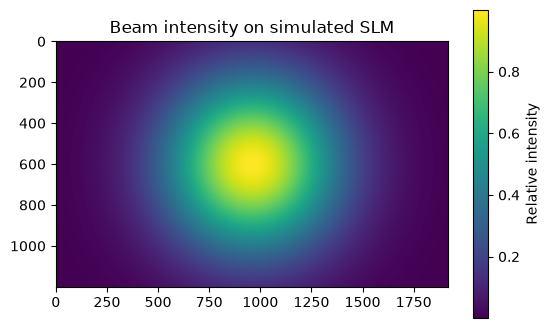

In [5]:
# --------------------------------------------------
# Gaussian illumination
# --------------------------------------------------

Ny, Nx = slm.shape

pitch_um = 8.0

x = (np.arange(Nx) - (Nx - 1)/2) * pitch_um
y = (np.arange(Ny) - (Ny - 1)/2) * pitch_um

X, Y = np.meshgrid(x, y)

# 9.6 mm 1/e^2 intensity diameter
w0_um = 4800.0       # 1/e^2 intensity radius

# Field amplitude.
# I = |A|^2 = exp(-2 r^2/w0^2)
amp = np.exp(-(X**2 + Y**2) / w0_um**2)

plt.figure(figsize=(19/3, 12/3))
plt.imshow(amp**2)
plt.colorbar(label="Relative intensity")
plt.title("Beam intensity on simulated SLM")
plt.show()

In [8]:
phase = np.zeros(slm.shape)

holo = Hologram(
    slm.shape,
    amp=amp,
    phase=phase,
    slm_shape=slm.shape
)

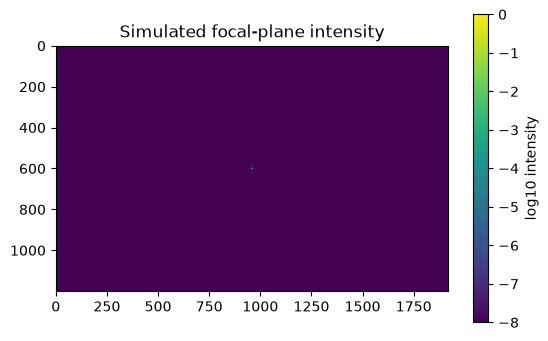

In [10]:
field_ff = holo.get_farfield()

intensity_ff = np.abs(field_ff)**2
intensity_ff /= intensity_ff.max()

plt.figure(figsize=(19/3, 12/3))
plt.imshow(np.log10(intensity_ff + 1e-8))
plt.colorbar(label="log10 intensity")
plt.title("Simulated focal-plane intensity")
plt.show()